# 07 — Triple Barrier Label Analysis

Analisa os labels gerados pelo método Triple Barrier Method (TBM) para um ativo selecionado.

**Seções:**
1. Configuração do ativo e parâmetros
2. Série de preço com labels por dia
3. Distribuição de labels por ano
4. Histograma de duração dos eventos
5. Zoom: visualização das barreiras em período recente
6. Análise de sensibilidade dos parâmetros (pt_sl, vol_span, time_horizon)
7. Distribuição comparativa — todos os ativos
8. Métricas financeiras da rotulagem (oracle: labels verdadeiros como previsão perfeita)


In [1]:
# ── CONFIGURAÇÃO ─────────────────────────────────────────────────────────────
# Altere apenas estas variáveis para analisar um ativo diferente.

TICKER = "ABEV3.SA"          # qualquer ticker em TICKERS (config/experiment_config.py)
ZOOM_START = "2021-01-01"    # início do período de zoom (visualização de barreiras)
ZOOM_END   = "2023-12-31"    # fim do período de zoom

# Parâmetros atuais (usados para linhas de referência na análise de sensibilidade)
CURRENT_PT_SL      = [2.0, 2.0]
CURRENT_VOL_SPAN   = 100
CURRENT_TIME_HORIZ = 10

In [2]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Paths
_HERE  = Path().resolve()
_ROOT  = _HERE.parent.parent
sys.path.insert(0, str(_ROOT))
sys.path.insert(0, str(_HERE))

from config.experiment_config import TICKERS, LABELING_CONFIG
from src.data_loader import load_raw, LABELS_DIR
from utils.labeling import get_daily_vol, triple_barrier_labeling

# Style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

COLORS  = {0: '#e74c3c', 1: '#bdc3c7', 2: '#27ae60'}  # sell / hold / buy
MARKERS = {0: 'v',       1: 's',       2: '^'}
CNAMES  = {0: 'Sell',    1: 'Hold',    2: 'Buy'}

assert TICKER in TICKERS, f"{TICKER} not in TICKERS — check config/experiment_config.py"
print(f"Analisando: {TICKER}   zoom: {ZOOM_START} → {ZOOM_END}")

I0000 00:00:1777770887.593933  280541 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Analisando: ABEV3.SA   zoom: 2021-01-01 → 2023-12-31


In [3]:
# ── Carrega dados ─────────────────────────────────────────────────────────────
raw_df = load_raw(TICKER)
close  = raw_df['Close']

lbl_df   = pd.read_parquet(LABELS_DIR / f'{TICKER}.parquet')
labels   = lbl_df['label']
t1       = lbl_df['t1'] if 't1' in lbl_df.columns else None

# Alinha com close
common = labels.index.intersection(close.index)
labels = labels.loc[common]
close_lbl = close.loc[common]
t1_lbl    = t1.loc[common] if t1 is not None else None

# Estatísticas básicas
n = len(labels)
print(f"Total de amostras : {n}")
print(f"Período           : {labels.index[0].date()} → {labels.index[-1].date()}")
print()
for lbl, name in CNAMES.items():
    cnt = (labels == lbl).sum()
    print(f"  {name:4s}: {cnt:5d} ({cnt/n*100:.1f}%)")

if t1_lbl is not None:
    dur_days = (t1_lbl - pd.Series(labels.index, index=labels.index)).dt.days
    print(f"\nDuração média do evento: {dur_days.mean():.1f} dias calendario")
    print(f"Mediana             : {dur_days.median():.1f} dias")
    vert_cal = CURRENT_TIME_HORIZ * 7 / 5  # aprox dias calendario
    print(f"Fração que atinge barreira de preço: {(dur_days < vert_cal).mean()*100:.1f}%")
    print(f"Fração que atinge barreira vertical: {(dur_days >= vert_cal).mean()*100:.1f}%")

Total de amostras : 5193
Período           : 2005-03-18 → 2026-02-06

  Sell:  1600 (30.8%)
  Hold:  1528 (29.4%)
  Buy :  2065 (39.8%)

Duração média do evento: 9.4 dias calendario
Mediana             : 9.0 dias
Fração que atinge barreira de preço: 64.1%
Fração que atinge barreira vertical: 35.9%


## 1 — Série completa com labels

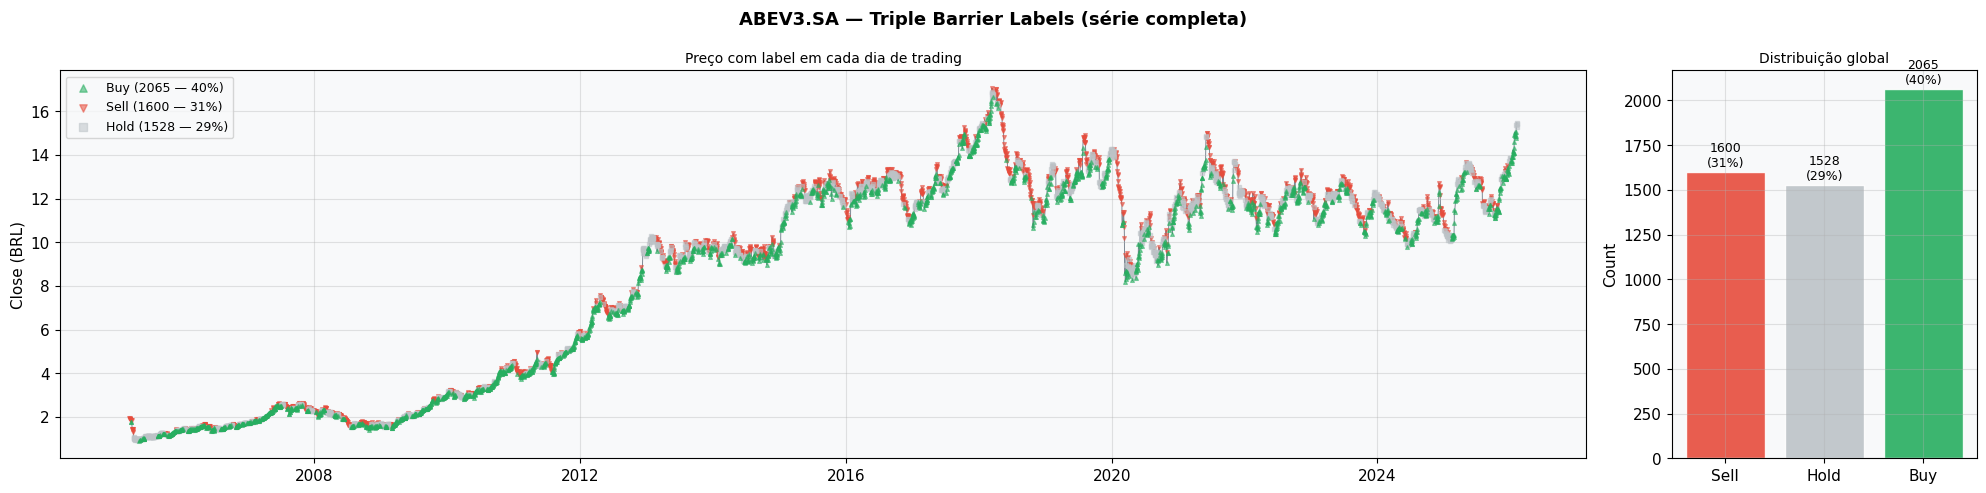

In [4]:
fig, (ax_price, ax_hist) = plt.subplots(
    1, 2, figsize=(20, 5),
    gridspec_kw={'width_ratios': [5, 1]},
)
fig.suptitle(f'{TICKER} — Triple Barrier Labels (série completa)', fontsize=13, fontweight='bold')

# Preço
ax_price.plot(close_lbl.index, close_lbl.values, color='#2c3e50', lw=0.7, alpha=0.6, zorder=1)

# Scatter por label (buy/sell em cima, hold embaixo)
for lbl in [2, 0, 1]:
    mask = labels == lbl
    ax_price.scatter(
        labels[mask].index,
        close_lbl[mask].values,
        c=COLORS[lbl], marker=MARKERS[lbl],
        s=7, alpha=0.55, zorder=2 + lbl,
        label=f"{CNAMES[lbl]} ({mask.sum()} — {mask.sum()/n*100:.0f}%)",
    )

ax_price.set_ylabel('Close (BRL)')
ax_price.legend(loc='upper left', fontsize=9, markerscale=2)
ax_price.set_title('Preço com label em cada dia de trading', fontsize=10)

# Distribuição global
cnts  = [int((labels == lbl).sum()) for lbl in [0, 1, 2]]
bars  = ax_hist.bar(
    [CNAMES[l] for l in [0, 1, 2]], cnts,
    color=[COLORS[l] for l in [0, 1, 2]],
    edgecolor='white', alpha=0.9,
)
for bar, v in zip(bars, cnts):
    ax_hist.text(bar.get_x() + bar.get_width()/2, bar.get_height() + n*0.003,
                 f'{v}\n({v/n*100:.0f}%)', ha='center', va='bottom', fontsize=9)
ax_hist.set_title('Distribuição global', fontsize=10)
ax_hist.set_ylabel('Count')

plt.tight_layout()
plt.show()

## 2 — Distribuição de labels por ano

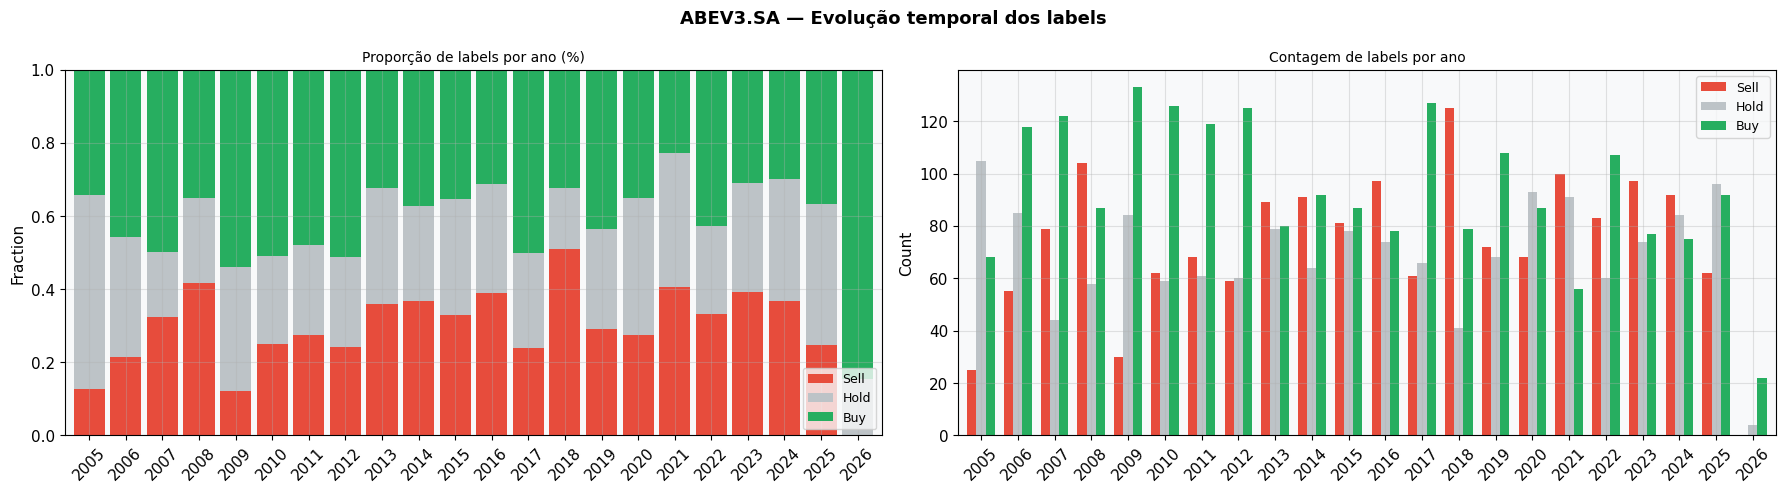

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle(f'{TICKER} — Evolução temporal dos labels', fontsize=13, fontweight='bold')

lbl_df_plot = pd.DataFrame({'label': labels, 'year': labels.index.year})

# Proporção por ano
yearly_pct = (
    lbl_df_plot.groupby('year')['label']
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .rename(columns=CNAMES)
    .reindex(columns=['Sell', 'Hold', 'Buy'], fill_value=0)
)
yearly_pct.plot(
    kind='bar', stacked=True,
    color=[COLORS[0], COLORS[1], COLORS[2]],
    ax=axes[0], width=0.85, legend=True,
)
axes[0].set_title('Proporção de labels por ano (%)', fontsize=10)
axes[0].set_ylabel('Fraction')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].set_ylim(0, 1)
axes[0].legend(loc='lower right', fontsize=9)

# Contagem por ano
yearly_cnt = (
    lbl_df_plot.groupby('year')['label']
    .value_counts()
    .unstack(fill_value=0)
    .rename(columns=CNAMES)
    .reindex(columns=['Sell', 'Hold', 'Buy'], fill_value=0)
)
yearly_cnt.plot(
    kind='bar', stacked=False,
    color=[COLORS[0], COLORS[1], COLORS[2]],
    ax=axes[1], width=0.75, legend=True,
)
axes[1].set_title('Contagem de labels por ano', fontsize=10)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## 3 — Histograma de duração dos eventos

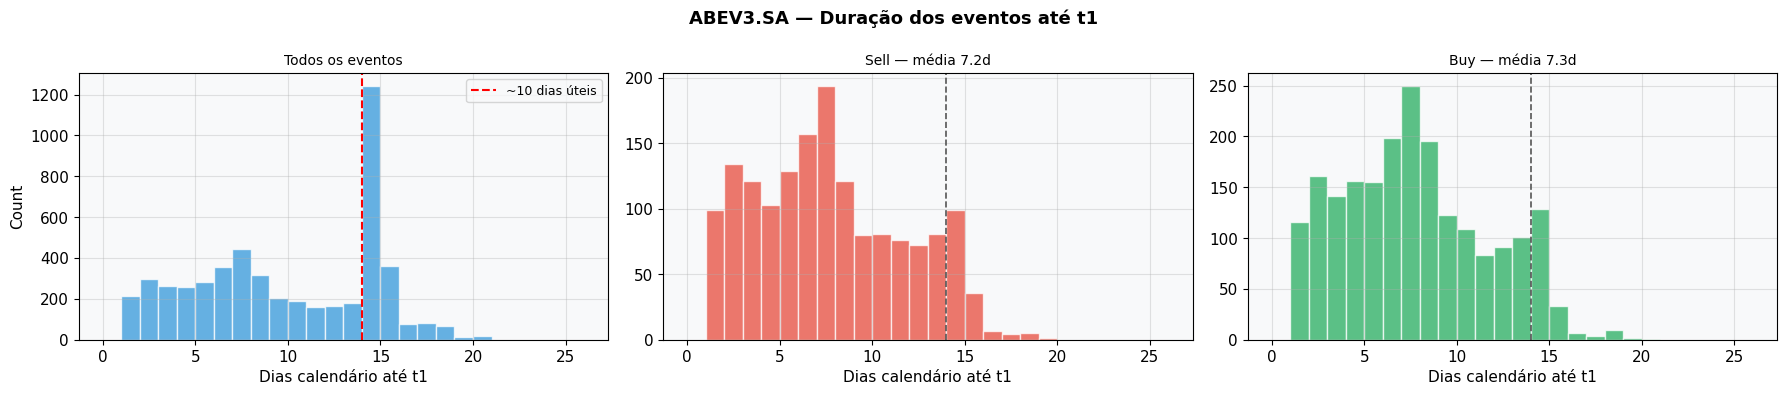


Label       N   Mean   Med  <vert  >=vert
----------------------------------------
Sell     1600   7.2d    7d    90%     10%
Hold     1528  14.6d   14d     0%    100%
Buy      2065   7.3d    7d    91%      9%


In [6]:
if t1_lbl is None:
    print("t1 não disponível — execute prepare_data.py primeiro.")
else:
    dur_days = (t1_lbl - pd.Series(labels.index, index=labels.index)).dt.days.clip(0, 25)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{TICKER} — Duração dos eventos até t1', fontsize=13, fontweight='bold')
    
    # Global
    axes[0].hist(dur_days, bins=range(0, 27), color='#3498db', alpha=0.75, edgecolor='white')
    vert_cal = int(round(CURRENT_TIME_HORIZ * 7 / 5))
    axes[0].axvline(vert_cal, color='red', ls='--', lw=1.5, label=f'~{CURRENT_TIME_HORIZ} dias úteis')
    axes[0].set_xlabel('Dias calendário até t1')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Todos os eventos', fontsize=10)
    axes[0].legend(fontsize=9)
    
    # Por label
    for ax, (lbl, name) in zip(axes[1:], [(0, 'Sell'), (2, 'Buy')]):
        mask = labels == lbl
        dur_lbl = dur_days[mask]
        ax.hist(dur_lbl, bins=range(0, 27), color=COLORS[lbl], alpha=0.75, edgecolor='white')
        ax.axvline(vert_cal, color='#555', ls='--', lw=1.2)
        ax.set_xlabel('Dias calendário até t1')
        ax.set_title(f'{name} — média {dur_lbl.mean():.1f}d', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Tabela por label
    print(f"\n{'Label':6s} {'N':>6} {'Mean':>6} {'Med':>5} {'<vert':>6} {'>=vert':>7}")
    print('-'*40)
    dur_all = (t1_lbl - pd.Series(labels.index, index=labels.index)).dt.days
    for lbl, name in CNAMES.items():
        mask = labels == lbl
        d = dur_all[mask]
        print(f"{name:6s} {mask.sum():>6} {d.mean():>5.1f}d {d.median():>4.0f}d {(d < vert_cal).mean()*100:>5.0f}% {(d >= vert_cal).mean()*100:>6.0f}%")

## 4 — Zoom: preço com barreiras visíveis

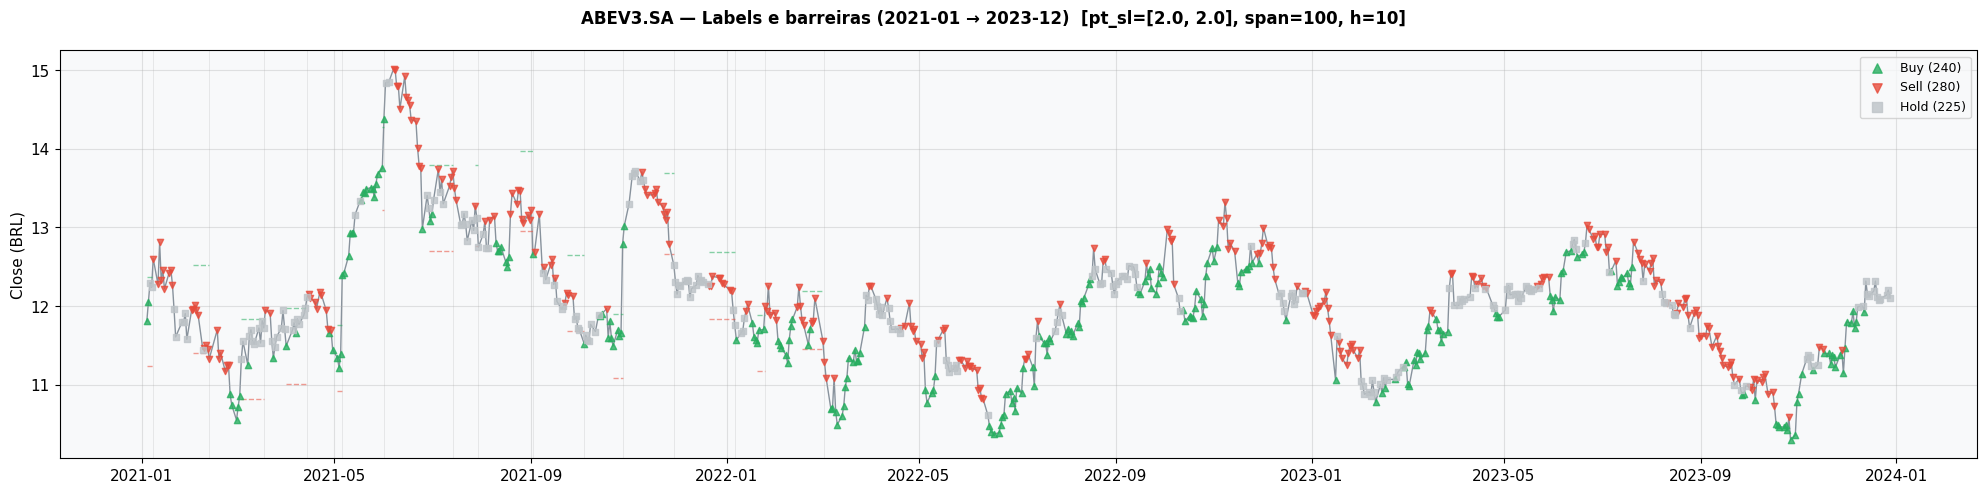

In [7]:
# Filtra período de zoom
zoom_mask = (labels.index >= ZOOM_START) & (labels.index <= ZOOM_END)
lbl_z  = labels[zoom_mask]
px_z   = close_lbl[zoom_mask]
t1_z   = t1_lbl[zoom_mask] if t1_lbl is not None else None

daily_vol = get_daily_vol(close, span=CURRENT_VOL_SPAN)
vol_z = daily_vol.reindex(px_z.index).ffill()

fig, ax = plt.subplots(figsize=(20, 5))
fig.suptitle(
    f'{TICKER} — Labels e barreiras ({ZOOM_START[:7]} → {ZOOM_END[:7]})  '
    f'[pt_sl={CURRENT_PT_SL}, span={CURRENT_VOL_SPAN}, h={CURRENT_TIME_HORIZ}]',
    fontsize=12, fontweight='bold',
)

ax.plot(px_z.index, px_z.values, color='#2c3e50', lw=1.0, alpha=0.55, zorder=1)

for lbl in [2, 0, 1]:
    mask = lbl_z == lbl
    ax.scatter(
        lbl_z[mask].index, px_z[mask].values,
        c=COLORS[lbl], marker=MARKERS[lbl],
        s=20, alpha=0.8, zorder=3, label=f"{CNAMES[lbl]} ({mask.sum()})",
    )

# Barreiras ilustrativas para amostras esparsas (cada 20 pontos)
if t1_z is not None:
    sample_idx = lbl_z.index[::20][:15]
    for date in sample_idx:
        if date not in vol_z.index or pd.isna(vol_z.loc[date]):
            continue
        v   = vol_z.loc[date]
        p0  = px_z.loc[date]
        tp  = p0 * (1 + CURRENT_PT_SL[0] * v)
        sl  = p0 * (1 - CURRENT_PT_SL[1] * v)
        t1d = t1_z.loc[date]
        ax.hlines([tp, sl], date, t1d, colors=['#27ae60','#e74c3c'], lw=1.0, ls='--', alpha=0.55)
        ax.axvline(t1d, color='#aaa', lw=0.4, alpha=0.4)

ax.set_ylabel('Close (BRL)')
ax.legend(loc='best', fontsize=9, markerscale=1.5)
plt.tight_layout()
plt.show()

## 5 — Análise de sensibilidade dos parâmetros

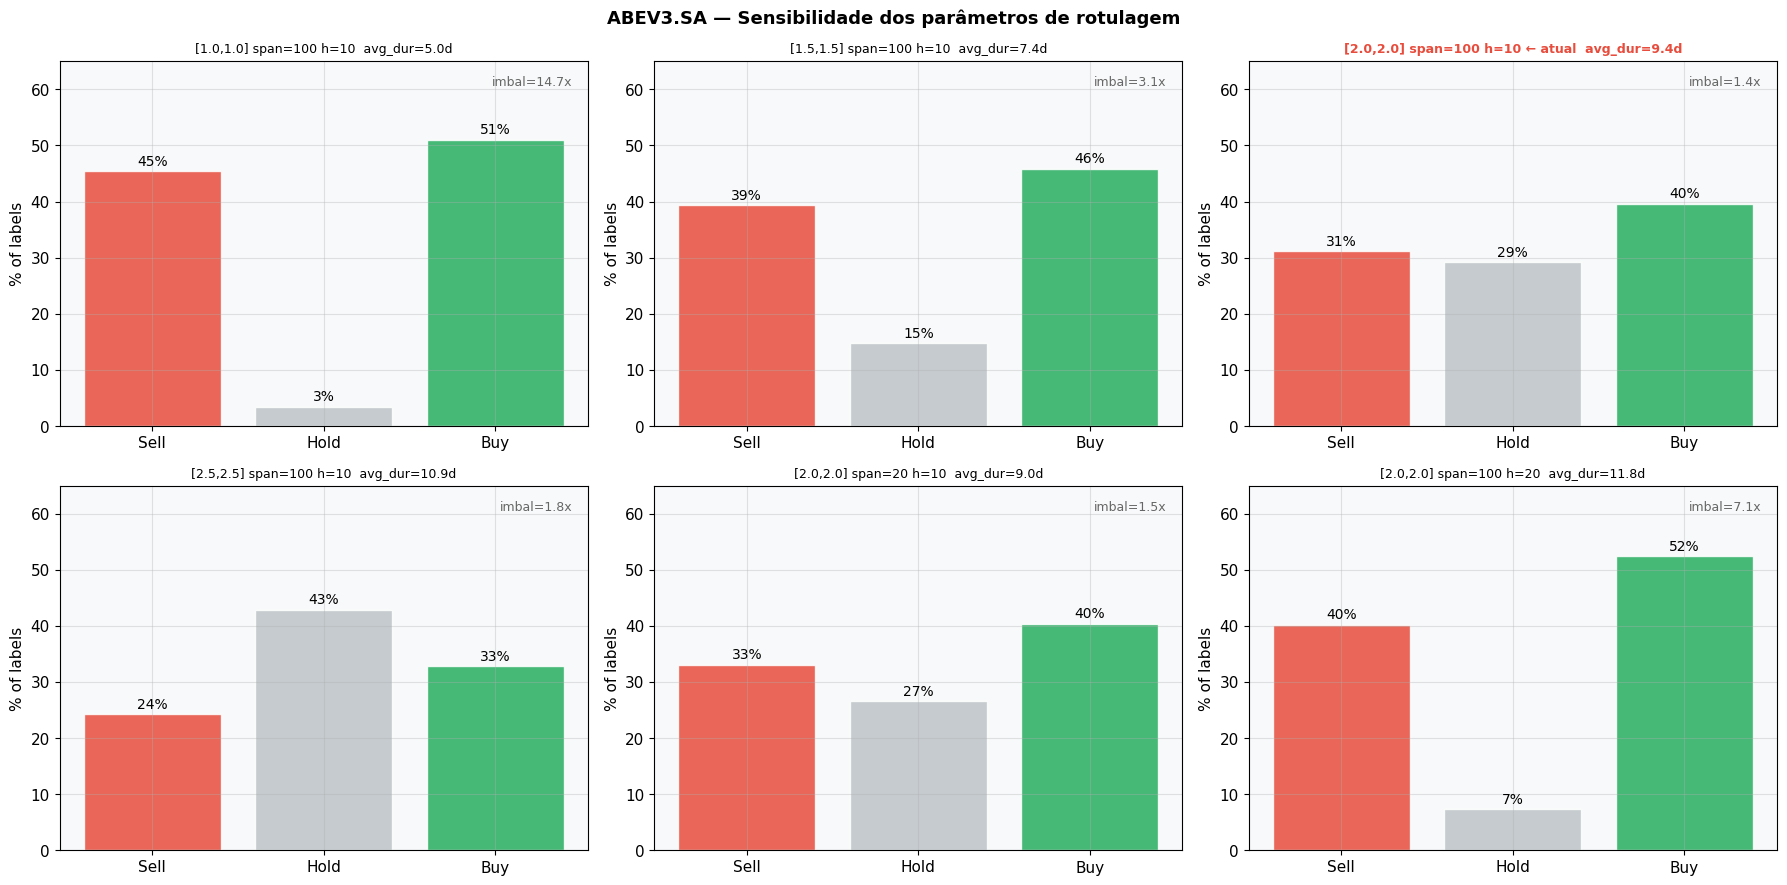


Config                               Sell%  Hold%   Buy%   Imbal   AvgDur
---------------------------------------------------------------------------
[1.0,1.0] span=100 h=10              45.5%    3.5%   51.1%    14.7x     5.0d
[1.5,1.5] span=100 h=10              39.3%   14.8%   45.9%     3.1x     7.4d
[2.0,2.0] span=100 h=10 ← atual      31.1%   29.2%   39.6%     1.4x     9.4d ←
[2.5,2.5] span=100 h=10              24.3%   42.9%   32.9%     1.8x    10.9d
[2.0,2.0] span=20 h=10               33.1%   26.6%   40.4%     1.5x     9.0d
[2.0,2.0] span=100 h=20              40.2%    7.3%   52.4%     7.1x    11.8d


In [8]:
# Configurações a testar (pt_sl, vol_span, time_horizon)
SENSITIVITY_CONFIGS = [
    ([1.0, 1.0], 100, 10),
    ([1.5, 1.5], 100, 10),
    ([2.0, 2.0], 100, 10),   # atual
    ([2.5, 2.5], 100, 10),
    ([2.0, 2.0],  20, 10),
    ([2.0, 2.0], 100, 20),
]

results = []
for pt_sl, vol_span, horizon in SENSITIVITY_CONFIGS:
    dv  = get_daily_vol(close, span=vol_span)
    lbl = triple_barrier_labeling(close=close, trgt=dv, pt_sl=pt_sl, min_ret=0.001, num_days=horizon)
    n_  = len(lbl)
    c   = lbl['label'].value_counts()
    sell, hold, buy = c.get(-1,0), c.get(0,0), c.get(1,0)
    is_current = (pt_sl == CURRENT_PT_SL and vol_span == CURRENT_VOL_SPAN and horizon == CURRENT_TIME_HORIZ)
    results.append({
        'label':  f'[{pt_sl[0]},{pt_sl[1]}] span={vol_span} h={horizon}' + (' ← atual' if is_current else ''),
        'pt_sl':   pt_sl, 'span': vol_span, 'horizon': horizon,
        'sell':   sell/n_*100, 'hold': hold/n_*100, 'buy': buy/n_*100,
        'imbal':  max(sell,hold,buy)/max(min(sell,hold,buy),1),
        'is_current': is_current,
    })
    if 't1' in lbl.columns:
        dur = (lbl['t1'] - lbl.index.to_series()).dt.days
        results[-1]['avg_dur'] = dur.mean()

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle(f'{TICKER} — Sensibilidade dos parâmetros de rotulagem', fontsize=13, fontweight='bold')

for ax, r in zip(axes.flat, results):
    vals = [r['sell'], r['hold'], r['buy']]
    bars = ax.bar([CNAMES[0], CNAMES[1], CNAMES[2]], vals,
                  color=[COLORS[0], COLORS[1], COLORS[2]], alpha=0.85, edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.0f}%', ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, 65)
    ax.set_ylabel('% of labels')
    dur_str = f"  avg_dur={r['avg_dur']:.1f}d" if 'avg_dur' in r else ''
    ax.set_title(
        r['label'] + dur_str,
        fontsize=9,
        fontweight='bold' if r['is_current'] else 'normal',
        color='#e74c3c' if r['is_current'] else 'black',
    )
    ax.text(0.97, 0.96, f'imbal={r["imbal"]:.1f}x', transform=ax.transAxes,
            ha='right', va='top', fontsize=9, color='#666')

plt.tight_layout()
plt.show()

# Tabela resumo
print(f"\n{'Config':<35} {'Sell%':>6} {'Hold%':>6} {'Buy%':>6} {'Imbal':>7} {'AvgDur':>8}")
print('-'*75)
for r in results:
    dur = f"{r['avg_dur']:.1f}d" if 'avg_dur' in r else '-'
    marker = ' ←' if r['is_current'] else ''
    print(f"{r['label']:<35} {r['sell']:>5.1f}%  {r['hold']:>5.1f}%  {r['buy']:>5.1f}%  {r['imbal']:>6.1f}x  {dur:>7}{marker}")

## 6 — Distribuição comparativa — todos os ativos

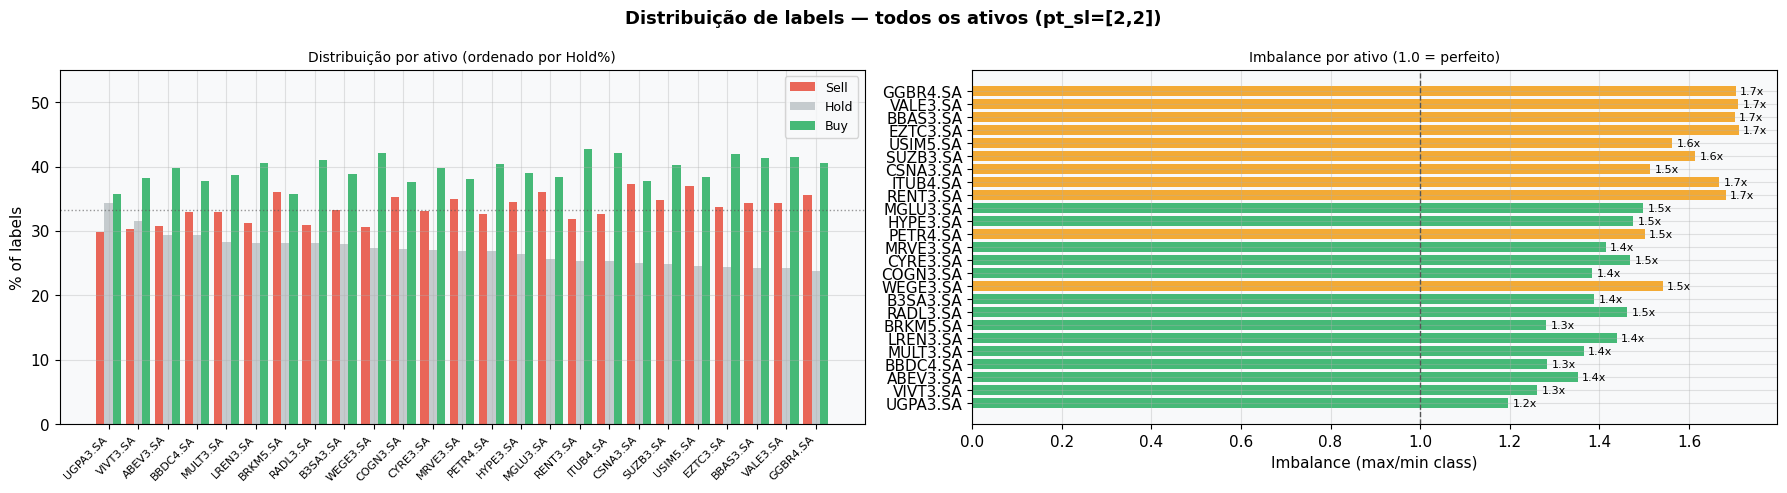


Hold%: média=27.0%  min=23.8%  max=34.3%
Imbalance: média=1.5x  max=1.7x


In [9]:
rows = []
for p in sorted(LABELS_DIR.glob('*.parquet')):
    df  = pd.read_parquet(p)
    lbl = df['label']
    n_  = len(lbl)
    c   = lbl.value_counts()
    rows.append({
        'ticker': p.stem,
        'n':      n_,
        'sell':   c.get(0,0)/n_*100,
        'hold':   c.get(1,0)/n_*100,
        'buy':    c.get(2,0)/n_*100,
        'imbal':  max(c.get(0,0), c.get(1,0), c.get(2,0)) / max(min(c.get(0,0), c.get(1,0), c.get(2,0)), 1),
    })

df_all = pd.DataFrame(rows).sort_values('hold', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle('Distribuição de labels — todos os ativos (pt_sl=[2,2])', fontsize=13, fontweight='bold')

# Grouped bar per ticker
x  = np.arange(len(df_all))
w  = 0.28
ax = axes[0]
ax.bar(x - w, df_all['sell'],  width=w, color=COLORS[0], alpha=0.85, label='Sell')
ax.bar(x,     df_all['hold'],  width=w, color=COLORS[1], alpha=0.85, label='Hold')
ax.bar(x + w, df_all['buy'],   width=w, color=COLORS[2], alpha=0.85, label='Buy')
ax.set_xticks(x)
ax.set_xticklabels(df_all['ticker'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% of labels')
ax.set_ylim(0, 55)
ax.legend(fontsize=9)
ax.axhline(33.3, color='#555', ls=':', lw=1.0, alpha=0.6, label='balanced')
ax.set_title('Distribuição por ativo (ordenado por Hold%)', fontsize=10)

# Imbalance
axes[1].barh(df_all['ticker'], df_all['imbal'],
             color=['#e74c3c' if v > 2 else '#f39c12' if v > 1.5 else '#27ae60' for v in df_all['imbal']],
             alpha=0.85)
axes[1].axvline(1.0, color='#555', ls='--', lw=1.0)
axes[1].set_xlabel('Imbalance (max/min class)')
axes[1].set_title('Imbalance por ativo (1.0 = perfeito)', fontsize=10)
for i, (_, row) in enumerate(df_all.iterrows()):
    axes[1].text(row['imbal'] + 0.01, i, f"{row['imbal']:.1f}x", va='center', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nHold%: média={df_all['hold'].mean():.1f}%  min={df_all['hold'].min():.1f}%  max={df_all['hold'].max():.1f}%")
print(f"Imbalance: média={df_all['imbal'].mean():.1f}x  max={df_all['imbal'].max():.1f}x")

## 7 — Retornos de evento vs retornos diários

Comparação do retorno acumulado até `t1` (multi-day, consistente com o label) vs retorno do próximo dia (backtest antigo).

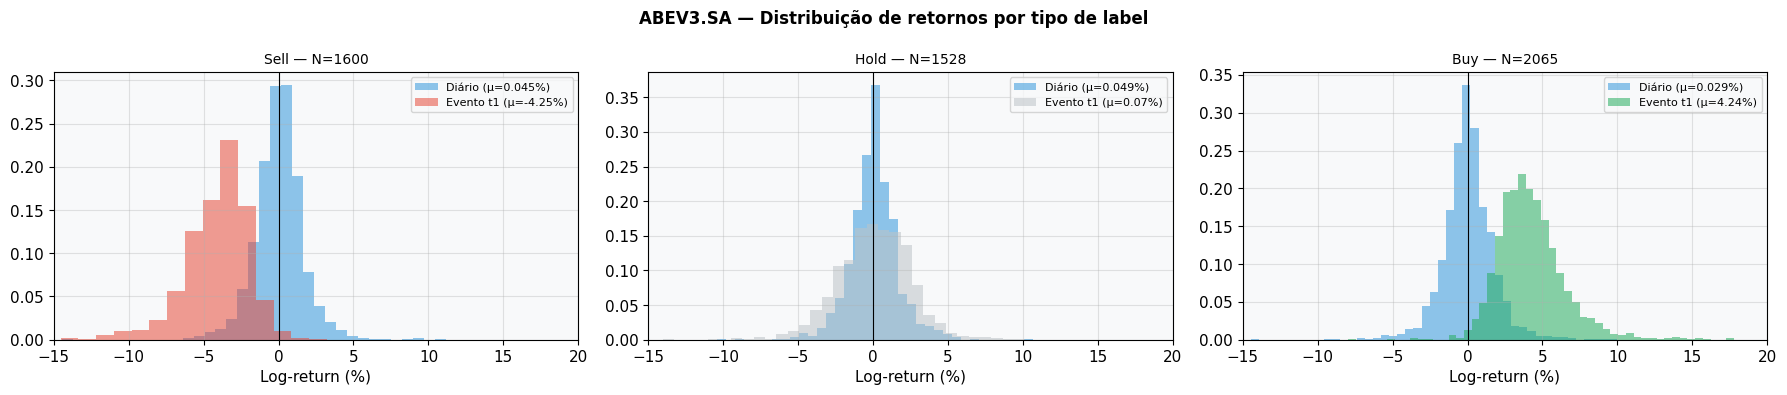


Label    Daily mean   Event mean  Daily std  Event std
-------------------------------------------------------
Sell       0.0452%      -4.253%     1.768%     2.977%
Hold       0.0489%       0.069%     1.684%     2.562%
Buy        0.0294%       4.240%     1.765%     2.278%

Nota: Event mean positivo para Buy e negativo para Sell indica que os labels são informativos.
      Daily mean próximo de zero é esperado (mismatch horizonte 10d vs 1d).


In [10]:
if t1_lbl is None:
    print("t1 não disponível.")
else:
    # Retorno diário do dia seguinte ao label
    log_ret = np.log(close / close.shift(1))
    log_ret_aligned = log_ret.reindex(labels.index)

    # Retorno de evento: acumulado de d até t1[d]
    from src.data_loader import load_raw
    dates_arr = labels.index
    date_to_pos = {d: i for i, d in enumerate(dates_arr)}
    log_ret_vals = log_ret_aligned.values

    event_rets = np.zeros(len(dates_arr))
    for i, date in enumerate(dates_arr):
        t1d = t1_lbl.loc[date]
        end_pos = date_to_pos.get(t1d, min(i + CURRENT_TIME_HORIZ, len(dates_arr)-1))
        if end_pos > i:
            event_rets[i] = float(np.nansum(log_ret_vals[i:end_pos+1]))
        else:
            event_rets[i] = log_ret_vals[i] if not np.isnan(log_ret_vals[i]) else 0.0

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f'{TICKER} — Distribuição de retornos por tipo de label', fontsize=12, fontweight='bold')

    for ax, (lbl, name) in zip(axes, [(0,'Sell'), (1,'Hold'), (2,'Buy')]):
        mask = labels.values == lbl
        daily_r = log_ret_vals[mask]
        event_r = event_rets[mask]

        # Remove NaN
        daily_r = daily_r[np.isfinite(daily_r)]
        event_r = event_r[np.isfinite(event_r)]

        ax.hist(daily_r * 100, bins=50, alpha=0.55, color='#3498db', label=f'Diário (μ={daily_r.mean()*100:.3f}%)', density=True)
        ax.hist(event_r * 100, bins=50, alpha=0.55, color=COLORS[lbl], label=f'Evento t1 (μ={event_r.mean()*100:.2f}%)', density=True)
        ax.axvline(0, color='black', lw=0.8)
        ax.set_xlabel('Log-return (%)')
        ax.set_title(f'{name} — N={mask.sum()}', fontsize=10)
        ax.legend(fontsize=8)
        ax.set_xlim(-15, 20)

    plt.tight_layout()
    plt.show()

    # Tabela: separação de retornos médios por label
    print(f"\n{'Label':<6} {'Daily mean':>12} {'Event mean':>12} {'Daily std':>10} {'Event std':>10}")
    print('-'*55)
    for lbl, name in CNAMES.items():
        mask = labels.values == lbl
        d = log_ret_vals[mask]
        e = event_rets[mask]
        d = d[np.isfinite(d)]; e = e[np.isfinite(e)]
        print(f"{name:<6} {d.mean()*100:>10.4f}%  {e.mean()*100:>10.3f}%  {d.std()*100:>8.3f}%  {e.std()*100:>8.3f}%")
    
    print("\nNota: Event mean positivo para Buy e negativo para Sell indica que os labels são informativos.")
    print("      Daily mean próximo de zero é esperado (mismatch horizonte 10d vs 1d).")

## 8 — Métricas financeiras da rotulagem (oracle)

Simula uma estratégia **oracle** que conhece os labels verdadeiros e os usa como previsão perfeita.
Isso representa o **teto de desempenho** alcançável pela rotulagem com as configurações atuais —
qualquer modelo treinado estará abaixo desses valores.

As métricas são calculadas com exatamente as mesmas funções do pipeline de experimentos:
`simulate_strategy` + `FinancialMetrics.compute` com retornos de evento acumulados até `t1`.


Métrica                   Oracle (labels)   Buy-and-Hold
════════════════════════════════════════════════════════
  Sharpe ratio                    +13.780         +0.364
  Sortino ratio                   +29.396         +0.467
  Calmar ratio                  +4021.769         +0.112
  CAGR                          +84178.2%          +6.4%
  Max Drawdown                     -20.9%         -56.9%
  Volatility (ann.)                 50.4%          27.7%
  Win Rate                          81.5%          51.5%
  Profit Factor                     22.66           1.07
  Avg Win                         +0.0445        +0.0124
  Avg Loss                        -0.0087        -0.0123
  VaR 95%                         -0.0054        -0.0255
  CVaR 95%                        -0.0233        -0.0392
  Total Return         +195268865574516176049620048110832557483957226157664733780508672.0%        +258.6%
  Jensen α (ann.)                 +6.9499            N/A
  Beta vs B&H                      -0.0

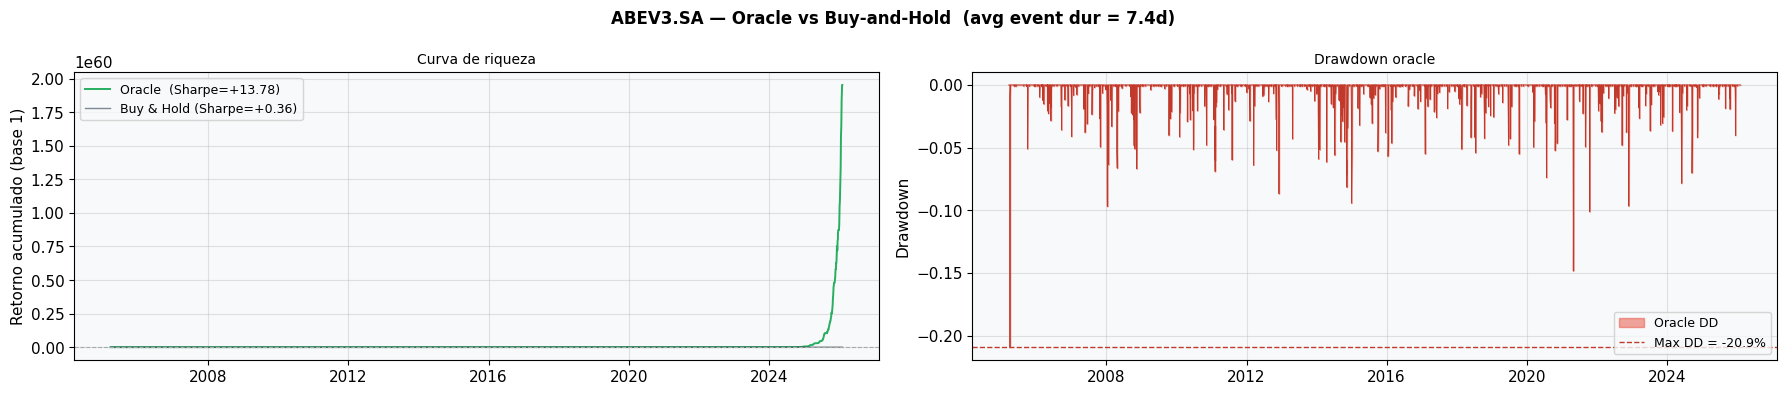

In [13]:
from src.evaluation import FinancialMetrics
from src.backtest import simulate_strategy

TRANSACTION_COST = 0.001   # mesmo padrão do pipeline
ALLOW_SHORT      = True
ANNUAL_RF        = 0.0

# ── Retornos simples diários e de evento ──────────────────────────────────────
# expm1(log_return) = pct_change exato; todas as métricas assumem retorno simples
log_ret   = np.log(close / close.shift(1))
daily_r   = np.expm1(log_ret.reindex(labels.index)).values.astype(np.float32)

# Replica _compute_event_returns do pipeline (retorno simples composto)
def _event_returns(daily_rets, t1_series, dates):
    n = len(dates)
    ev = daily_rets.copy()
    date_to_pos = {d: i for i, d in enumerate(dates)}
    durations = []
    for i, date in enumerate(dates):
        if t1_series is None or date not in t1_series.index or pd.isna(t1_series.loc[date]):
            durations.append(1)
            continue
        t1d = t1_series.loc[date]
        end_pos = date_to_pos.get(t1d, min(i + CURRENT_TIME_HORIZ, n - 1))
        if end_pos > i:
            # prod(1+r) - 1: composição correta de retornos simples
            ev[i] = float(np.prod(1.0 + daily_rets[i + 1: end_pos + 1]) - 1.0)
            durations.append(end_pos - i + 1)
        else:
            ev[i] = 0.0
            durations.append(1)
    return ev, float(np.mean(durations)) if durations else 1.0

ev_rets, avg_dur = _event_returns(daily_r, t1_lbl, labels.index)

# ── Oracle: labels verdadeiros como previsão perfeita ─────────────────────────
oracle_strat = simulate_strategy(
    labels.values,
    returns=pd.Series(ev_rets, index=labels.index),
    transaction_cost=TRANSACTION_COST,
    allow_short=ALLOW_SHORT,
    position_lag=0,
 )
oracle_strat.index = labels.index

# ── Buy-and-hold (benchmark no mesmo horizonte do evento) ───────────────────
bh_strat = pd.Series(ev_rets, index=labels.index).fillna(0)

oracle_metrics = FinancialMetrics.compute(
    oracle_strat, bh_strat,
    risk_free=ANNUAL_RF,
    return_horizon=avg_dur,
 )
bh_metrics = FinancialMetrics.compute(
    bh_strat,
    risk_free=ANNUAL_RF,
    return_horizon=avg_dur,
 )

# ── Tabela comparativa ────────────────────────────────────────────────────────
DISPLAY_METRICS = [
    ("sharpe",        "Sharpe ratio",      "{:+.3f}"),
    ("sortino",       "Sortino ratio",     "{:+.3f}"),
    ("calmar",        "Calmar ratio",      "{:+.3f}"),
    ("cagr",          "CAGR",              "{:+.1%}"),
    ("max_drawdown",  "Max Drawdown",      "{:.1%}"),
    ("volatility_ann","Volatility (ann.)", "{:.1%}"),
    ("win_rate",      "Win Rate",          "{:.1%}"),
    ("profit_factor", "Profit Factor",     "{:.2f}"),
    ("avg_win",       "Avg Win",           "{:+.4f}"),
    ("avg_loss",      "Avg Loss",          "{:+.4f}"),
    ("var_95",        "VaR 95%",           "{:.4f}"),
    ("cvar_95",       "CVaR 95%",          "{:.4f}"),
    ("total_return",  "Total Return",      "{:+.1%}"),
    ("alpha",         "Jensen α (ann.)",   "{:+.4f}"),
    ("beta",          "Beta vs B&H",       "{:+.3f}"),
]

print(f"{'Métrica':<22} {'Oracle (labels)':>18} {'Buy-and-Hold':>14}")
print("═" * 56)
for key, name, fmt in DISPLAY_METRICS:
    o_val = oracle_metrics.get(key, float("nan"))
    b_val = bh_metrics.get(key, float("nan"))
    o_str = fmt.format(o_val) if not np.isnan(o_val) else "  N/A"
    b_str = fmt.format(b_val) if not np.isnan(b_val) else "  N/A"
    print(f"  {name:<20} {o_str:>18} {b_str:>14}")

print(f"\n  {'Avg event duration':<20} {avg_dur:>17.1f}d {'same horizon':>14}")
print(f"  {'Transaction cost':<20} {TRANSACTION_COST:>17.1%} {'—':>14}")

# ── Curva de riqueza ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 4))
fig.suptitle(f'{TICKER} — Oracle vs Buy-and-Hold  (avg event dur = {avg_dur:.1f}d)', fontsize=12, fontweight='bold')

cum_oracle = (1 + oracle_strat).cumprod()
cum_bh     = (1 + bh_strat).cumprod()

ax1.plot(cum_oracle.index, cum_oracle.values, color='#27ae60', lw=1.4, label=f"Oracle  (Sharpe={oracle_metrics['sharpe']:+.2f})")
ax1.plot(cum_bh.index,     cum_bh.values,     color='#2c3e50', lw=1.0, alpha=0.6, label=f"Buy & Hold (Sharpe={bh_metrics.get('bh_sharpe',bh_metrics['sharpe']):+.2f})")
ax1.axhline(1, color='#aaa', ls='--', lw=0.8)
ax1.set_ylabel('Retorno acumulado (base 1)')
ax1.set_title('Curva de riqueza', fontsize=10)
ax1.legend(fontsize=9)

# Drawdown oracle
dd_oracle = (cum_oracle / cum_oracle.cummax() - 1)
ax2.fill_between(dd_oracle.index, dd_oracle.values, 0, color='#e74c3c', alpha=0.5, label='Oracle DD')
ax2.plot(dd_oracle.index, dd_oracle.values, color='#c0392b', lw=0.6)
ax2.axhline(oracle_metrics['max_drawdown'], color='#c0392b', ls='--', lw=1.0,
            label=f"Max DD = {oracle_metrics['max_drawdown']:.1%}")
ax2.set_ylabel('Drawdown')
ax2.set_title('Drawdown oracle', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()


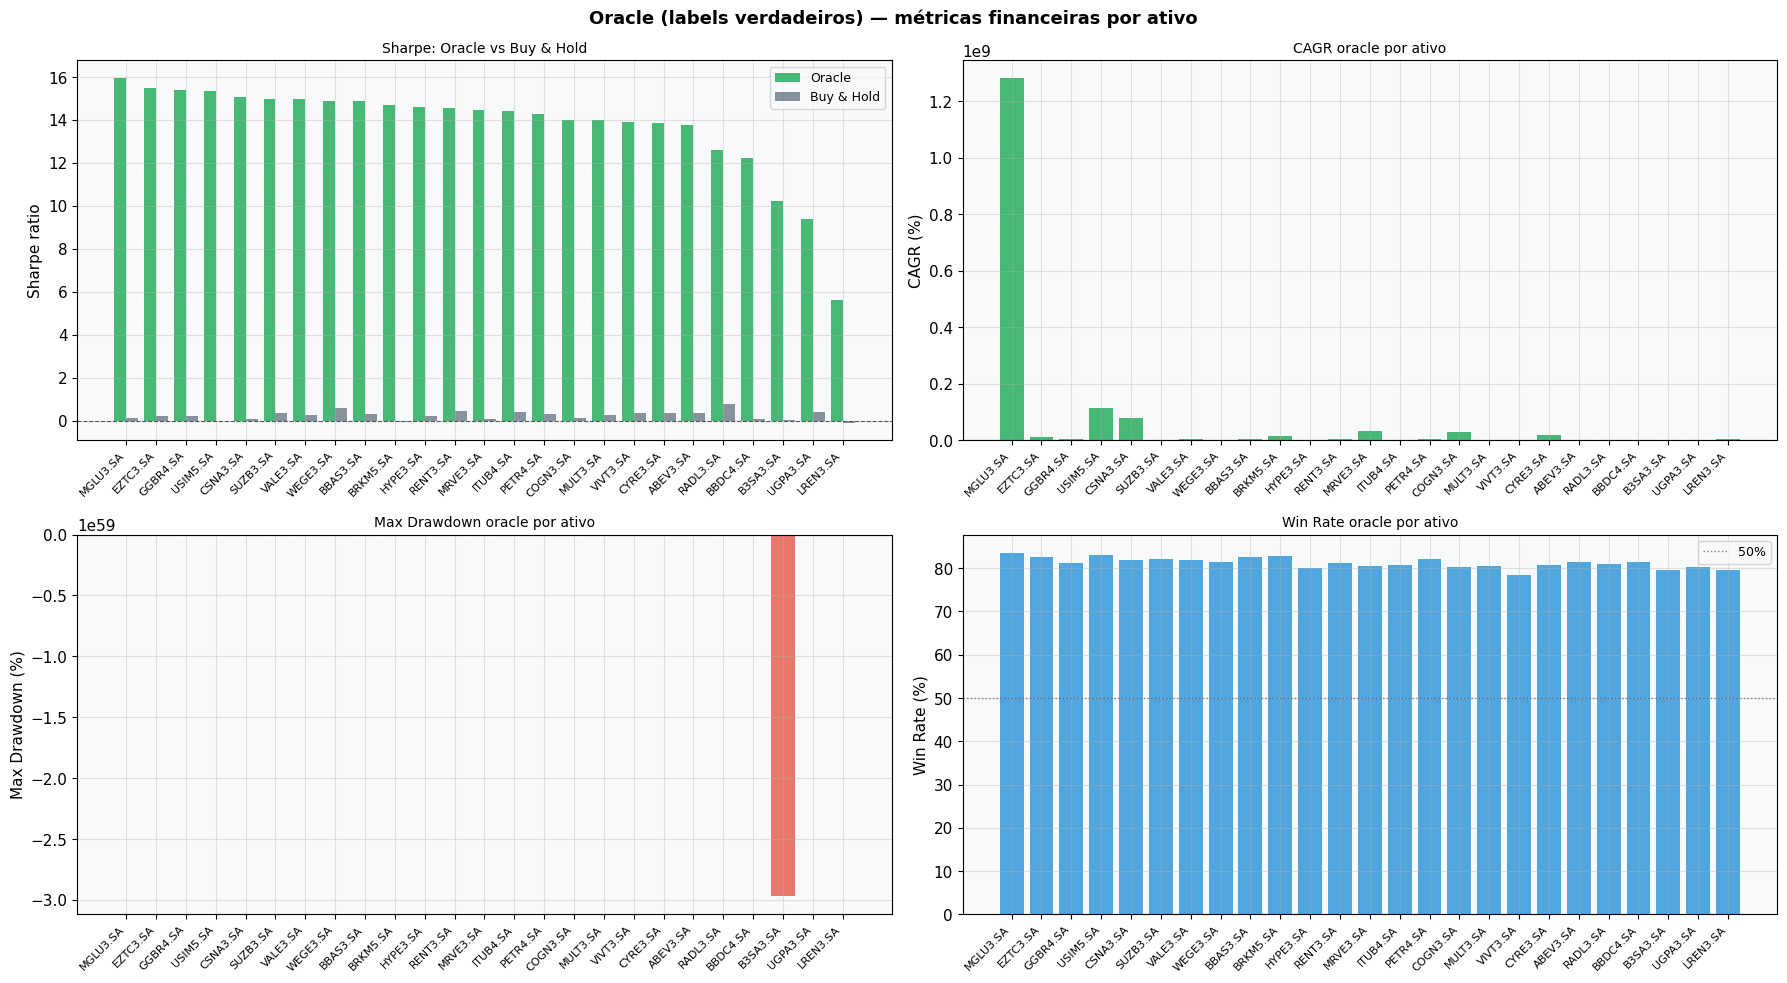


Ticker         Sharpe     CAGR      MDD   Sortino   Calmar   WinRate   AvgDur  BH Sharpe
──────────────────────────────────────────────────────────────────────────────────────────
  MGLU3.SA     +15.97 +1280764160.4%  -26.2%    +38.15 +48792041.50    83.6%     7.2d      +0.10
  EZTC3.SA     +15.48 +9642949.3%  -20.6%    +35.40 +467382.87    82.6%     7.1d      +0.22
  GGBR4.SA     +15.40 +3788060.7%  -39.6%    +34.03 +95756.37    81.2%     7.1d      +0.23
  USIM5.SA     +15.35 +113212170.8%  -24.0%    +36.55 +4716845.63    83.0%     7.1d      -0.04
  CSNA3.SA     +15.06 +79208038.8%  -48.8%    +32.51 +1622745.09    81.8%     7.1d      +0.09
  SUZB3.SA     +14.98 +1956583.3%  -15.5%    +38.36 +125923.13    82.2%     7.2d      +0.38
  VALE3.SA     +14.97 +2701820.2%  -21.8%    +34.03 +123674.71    81.9%     7.1d      +0.28
  WEGE3.SA     +14.87 +543806.3%  -31.5%    +38.34 +17287.38    81.4%     7.3d      +0.58
  BBAS3.SA     +14.87 +3343508.7%  -24.0%    +33.67 +139445.23    82.7%     

In [12]:
# ── Oracle metrics para TODOS os ativos ──────────────────────────────────────
all_rows = []

for p in sorted(LABELS_DIR.glob('*.parquet')):
    tkr = p.stem
    try:
        df_lbl = pd.read_parquet(p)
        lbl_all = df_lbl['label']
        t1_all  = df_lbl['t1'] if 't1' in df_lbl.columns else None

        raw_df_t = load_raw(tkr)
        close_t  = raw_df_t['Close']
        lr_t     = np.log(close_t / close_t.shift(1))

        common_t = lbl_all.index.intersection(close_t.index)
        lbl_all  = lbl_all.loc[common_t]
        lr_t     = lr_t.reindex(common_t).values.astype(np.float32)
        t1_t     = t1_all.loc[common_t] if t1_all is not None else None

        ev_t, avg_dur_t = _event_returns(lr_t, t1_t, common_t)

        oracle_t = simulate_strategy(
            lbl_all.values,
            returns=pd.Series(ev_t, index=common_t),
            transaction_cost=TRANSACTION_COST,
            allow_short=ALLOW_SHORT,
            position_lag=0,
        )
        oracle_t.index = common_t
        bh_t = pd.Series(ev_t, index=common_t).fillna(0)

        m_oracle = FinancialMetrics.compute(oracle_t, bh_t, risk_free=ANNUAL_RF, return_horizon=avg_dur_t)
        m_bh     = FinancialMetrics.compute(bh_t, risk_free=ANNUAL_RF, return_horizon=avg_dur_t)

        all_rows.append({
            'ticker':         tkr,
            'oracle_sharpe':  m_oracle['sharpe'],
            'oracle_cagr':    m_oracle['cagr'],
            'oracle_mdd':     m_oracle['max_drawdown'],
            'oracle_sortino': m_oracle['sortino'],
            'oracle_calmar':  m_oracle['calmar'],
            'oracle_winrate': m_oracle['win_rate'],
            'bh_sharpe':      m_bh['sharpe'],
            'bh_cagr':        m_bh['cagr'],
            'avg_dur':        avg_dur_t,
        })
    except Exception as exc:
        print(f"  ⚠  {tkr}: {exc}")

df_oracle = pd.DataFrame(all_rows).sort_values('oracle_sharpe', ascending=False).reset_index(drop=True)

# ── Visualização ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Oracle (labels verdadeiros) — métricas financeiras por ativo', fontsize=13, fontweight='bold')

# Sharpe oracle vs B&H
x_pos = np.arange(len(df_oracle))
ax = axes[0, 0]
ax.bar(x_pos - 0.2, df_oracle['oracle_sharpe'], width=0.4, color='#27ae60', alpha=0.85, label='Oracle')
ax.bar(x_pos + 0.2, df_oracle['bh_sharpe'],     width=0.4, color='#2c3e50', alpha=0.55, label='Buy & Hold')
ax.axhline(0, color='#555', ls='--', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_oracle['ticker'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sharpe ratio')
ax.set_title('Sharpe: Oracle vs Buy & Hold', fontsize=10)
ax.legend(fontsize=9)

# CAGR oracle
ax = axes[0, 1]
colors_cagr = ['#27ae60' if v > 0 else '#e74c3c' for v in df_oracle['oracle_cagr']]
ax.bar(x_pos, df_oracle['oracle_cagr'] * 100, color=colors_cagr, alpha=0.85)
ax.axhline(0, color='#555', ls='--', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_oracle['ticker'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CAGR (%)')
ax.set_title('CAGR oracle por ativo', fontsize=10)

# Max Drawdown oracle
ax = axes[1, 0]
ax.bar(x_pos, df_oracle['oracle_mdd'] * 100, color='#e74c3c', alpha=0.75)
ax.axhline(0, color='#555', ls='--', lw=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(df_oracle['ticker'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Max Drawdown oracle por ativo', fontsize=10)

# Win Rate oracle
ax = axes[1, 1]
ax.bar(x_pos, df_oracle['oracle_winrate'] * 100, color='#3498db', alpha=0.85)
ax.axhline(50, color='#555', ls=':', lw=1.0, alpha=0.7, label='50%')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_oracle['ticker'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Win Rate (%)')
ax.set_title('Win Rate oracle por ativo', fontsize=10)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── Tabela resumo ─────────────────────────────────────────────────────────────
print(f"\n{'Ticker':<12} {'Sharpe':>8} {'CAGR':>8} {'MDD':>8} {'Sortino':>9} {'Calmar':>8} {'WinRate':>9} {'AvgDur':>8} {'BH Sharpe':>10}")
print("─" * 90)
for _, row in df_oracle.iterrows():
    print(
        f"  {row['ticker']:<10} "
        f"{row['oracle_sharpe']:>+8.2f} "
        f"{row['oracle_cagr']:>+7.1%} "
        f"{row['oracle_mdd']:>+7.1%} "
        f"{row['oracle_sortino']:>+9.2f} "
        f"{row['oracle_calmar']:>+8.2f} "
        f"{row['oracle_winrate']:>8.1%} "
        f"{row['avg_dur']:>7.1f}d "
        f"{row['bh_sharpe']:>+10.2f}"
    )

print(f"\n  {'Média oracle':<10} "
      f"{df_oracle['oracle_sharpe'].mean():>+8.2f} "
      f"{df_oracle['oracle_cagr'].mean():>+7.1%} "
      f"{df_oracle['oracle_mdd'].mean():>+7.1%} "
      f"{df_oracle['oracle_sortino'].mean():>+9.2f}")
print("\nNota: Valores acima representam o teto de desempenho financeiro da rotulagem atual.")
print("      Modelos treinados terão métricas inferiores — a diferença é o 'custo' do erro de previsão.")

## 9 — Deriva IS vs OOS (distribution shift)

Compara a distribuição de labels no período **In-Sample** (tudo antes do início do bloco OOS)
com o período **Out-of-Sample** (`test_years` anos finais).  
Métricas calculadas por ticker:
- Distribuição relativa de classes (%)
- Divergência KL(IS ‖ OOS) — alerta se KL > 0.10
- Duração média dos eventos IS vs OOS (proxy de regime)


In [ ]:

import scipy.stats as stats

# ── Configuração ─────────────────────────────────────────────────────────────
TEST_YEARS = 6        # deve coincidir com VALIDATION_CONFIG["test_years"]
KL_ALERT   = 0.10     # KL-divergência acima deste valor indica deriva relevante

rows_shift = []

for tkr in TICKERS:
    p = LABELS_DIR / f"{tkr}.parquet"
    if not p.exists():
        continue
    df_t = pd.read_parquet(p)
    if "label" not in df_t.columns:
        continue

    # Identifica o corte IS/OOS
    oos_start = df_t.index.max() - pd.DateOffset(years=TEST_YEARS)
    is_mask   = df_t.index <= oos_start
    oos_mask  = df_t.index > oos_start

    lbl_is  = df_t.loc[is_mask,  "label"]
    lbl_oos = df_t.loc[oos_mask, "label"]

    if len(lbl_is) == 0 or len(lbl_oos) == 0:
        continue

    # Detecta classes presentes no dataset
    all_classes = sorted(set(df_t["label"].unique()))
    n_cls = len(all_classes)

    # Distribuições (com suavização Laplace para evitar log(0))
    def smooth_dist(lbl_series, classes, alpha=1e-6):
        counts = lbl_series.value_counts()
        v = np.array([counts.get(c, 0) + alpha for c in classes], dtype=float)
        return v / v.sum()

    dist_is  = smooth_dist(lbl_is,  all_classes)
    dist_oos = smooth_dist(lbl_oos, all_classes)

    # KL(IS ‖ OOS)
    kl = float(stats.entropy(dist_is, dist_oos))

    # Duração média dos eventos IF "t1" column present
    dur_is = dur_oos = float("nan")
    if "t1" in df_t.columns:
        t1_col = pd.to_datetime(df_t["t1"])
        durs   = (t1_col - df_t.index).dt.days
        dur_is  = float(durs[is_mask].mean())
        dur_oos = float(durs[oos_mask].mean())

    row = {"ticker": tkr, "n_is": len(lbl_is), "n_oos": len(lbl_oos),
           "kl_div": kl, "dur_is": dur_is, "dur_oos": dur_oos}
    for c in all_classes:
        label_name = {0: "sell", 1: "hold" if n_cls == 3 else "up", 2: "buy"}.get(c, str(c))
        row[f"is_{label_name}"]  = float((lbl_is == c).mean())
        row[f"oos_{label_name}"] = float((lbl_oos == c).mean())
    rows_shift.append(row)

df_shift = pd.DataFrame(rows_shift).set_index("ticker")

# ── Tabela resumo ─────────────────────────────────────────────────────────────
display_cols = ["n_is", "n_oos", "kl_div", "dur_is", "dur_oos"]
fmt = {c: "{:.1f}" for c in display_cols if c not in {"n_is", "n_oos"}}
fmt.update({"n_is": "{:.0f}", "n_oos": "{:.0f}"})

print("=== KL-divergência IS‖OOS por ticker ===")
print(f"(alerta se KL > {KL_ALERT})\n")
summary = df_shift[display_cols].copy()
summary["alerta"] = summary["kl_div"].apply(lambda x: "⚠" if x > KL_ALERT else "")
print(summary.to_string())


In [ ]:

# ── Gráfico de barras agrupadas: distribuição IS vs OOS por ticker ────────────
dist_cols_is  = [c for c in df_shift.columns if c.startswith("is_")]
dist_cols_oos = [c for c in df_shift.columns if c.startswith("oos_")]
class_keys    = [c.replace("is_", "") for c in dist_cols_is]

n_tickers = len(df_shift)
n_classes_plot = len(class_keys)
bar_width = 0.35
x = np.arange(n_tickers)

LABEL_COLORS = {"sell": "#e74c3c", "hold": "#bdc3c7", "buy": "#2ecc71",
                "up": "#2ecc71", "down": "#e74c3c"}

fig, axes = plt.subplots(1, n_classes_plot, figsize=(6 * n_classes_plot, 5), sharey=True)
if n_classes_plot == 1:
    axes = [axes]

for ax_, ck in zip(axes, class_keys):
    vals_is  = df_shift[f"is_{ck}"].values * 100
    vals_oos = df_shift[f"oos_{ck}"].values * 100
    color = LABEL_COLORS.get(ck, "#3498db")
    ax_.bar(x - bar_width/2, vals_is,  bar_width, label="IS",  color=color, alpha=0.8)
    ax_.bar(x + bar_width/2, vals_oos, bar_width, label="OOS", color=color, alpha=0.4, hatch="//")
    ax_.set_title(f"Classe '{ck}'")
    ax_.set_xticks(x)
    ax_.set_xticklabels(df_shift.index, rotation=45, ha="right", fontsize=8)
    ax_.set_ylabel("Frequência (%)")
    ax_.legend()
    ax_.set_ylim(0, 100)

fig.suptitle("Distribuição IS vs OOS por ticker e classe", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ── KL-divergência por ticker ─────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 4))
colors_kl = ["#e74c3c" if v > KL_ALERT else "#2ecc71" for v in df_shift["kl_div"]]
ax2.bar(df_shift.index, df_shift["kl_div"], color=colors_kl, edgecolor="black", linewidth=0.5)
ax2.axhline(KL_ALERT, color="orange", linestyle="--", label=f"Alerta KL={KL_ALERT}")
ax2.set_title("KL-divergência IS‖OOS (vermelho = deriva relevante)")
ax2.set_ylabel("KL(IS ‖ OOS)")
ax2.set_xticklabels(df_shift.index, rotation=45, ha="right", fontsize=8)
ax2.legend()
plt.tight_layout()
plt.show()

# ── Duração média IS vs OOS ───────────────────────────────────────────────────
if df_shift["dur_is"].notna().any():
    fig3, ax3 = plt.subplots(figsize=(12, 4))
    bw = 0.35
    x3 = np.arange(len(df_shift))
    ax3.bar(x3 - bw/2, df_shift["dur_is"],  bw, label="IS",  color="#3498db", alpha=0.8)
    ax3.bar(x3 + bw/2, df_shift["dur_oos"], bw, label="OOS", color="#e67e22", alpha=0.8)
    ax3.set_title("Duração média dos eventos (dias): IS vs OOS")
    ax3.set_ylabel("Dias médios / evento")
    ax3.set_xticks(x3)
    ax3.set_xticklabels(df_shift.index, rotation=45, ha="right", fontsize=8)
    ax3.legend()
    plt.tight_layout()
    plt.show()
